In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


DATA_DIR = Path.cwd()
INPUT_FILE = DATA_DIR / "processed" / "panel_data.csv"
VISUALS_DIR = DATA_DIR / "visuals"

VISUALS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(INPUT_FILE)

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["lgdp"] = pd.to_numeric(df["lgdp"], errors="coerce")
df["lerf"] = pd.to_numeric(df["lerf"], errors="coerce")

df = df.dropna(subset=["country", "year", "lgdp", "lerf"]).copy()
df = df.sort_values(["country", "year"]).reset_index(drop=True)

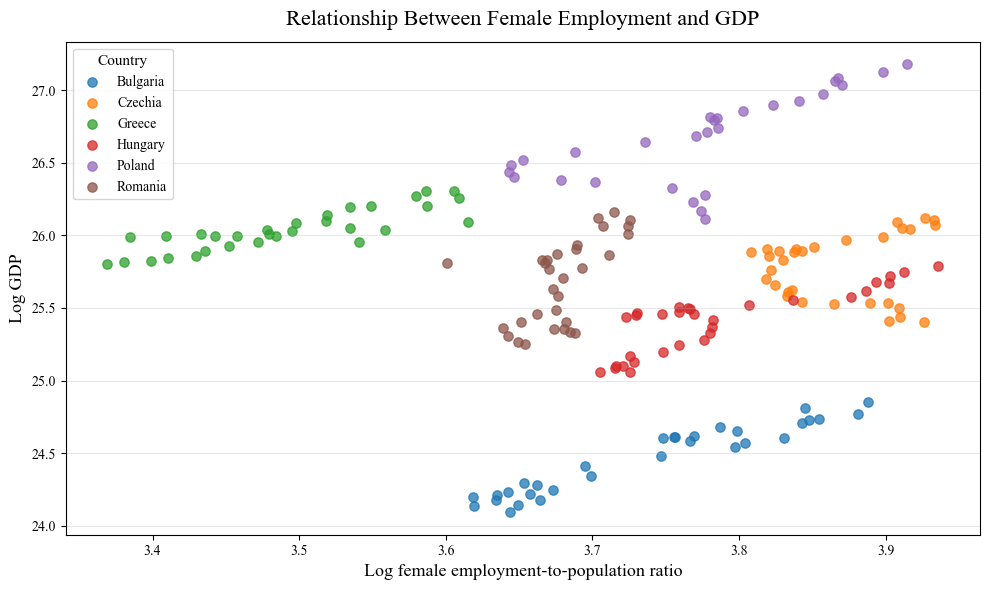

In [3]:
plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(10, 6))

for country, sub in df.groupby("country"):
    ax.scatter(
        sub["lerf"],
        sub["lgdp"],
        label=country,
        alpha=0.75,
        s=45
    )

ax.set_title(
    "Relationship Between Female Employment and GDP",
    fontsize=16,
    pad=12
)

ax.set_xlabel(
    "Log female employment-to-population ratio",
    fontsize=13
)

ax.set_ylabel(
    "Log GDP",
    fontsize=13
)

ax.grid(axis="y", alpha=0.3)
ax.legend(title="Country", fontsize=10, title_fontsize=11)

plt.tight_layout()

output_path = VISUALS_DIR / "scatter_female_employment_gdp.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

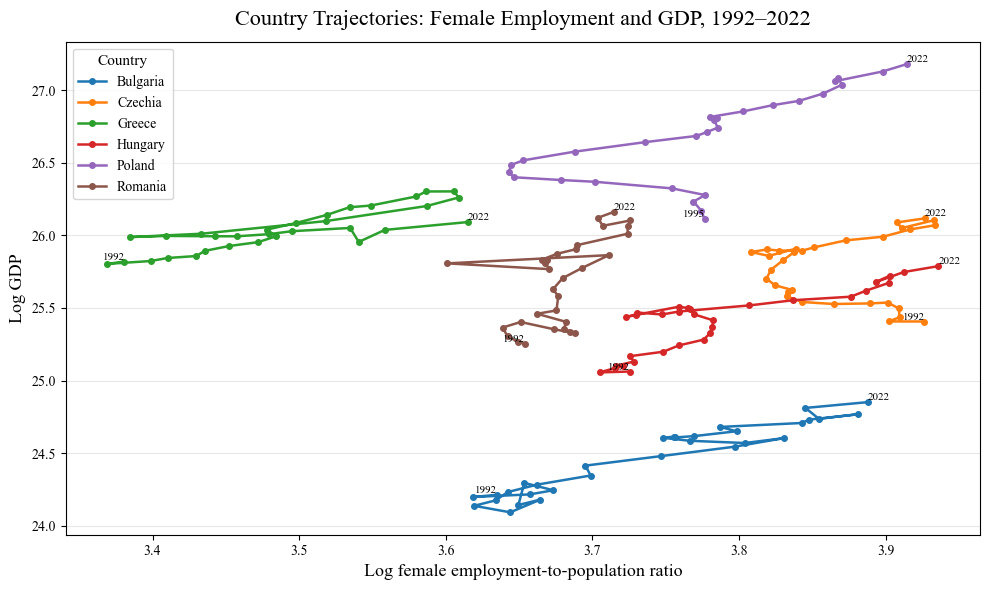

In [5]:
plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(10, 6))

for country, sub in df.groupby("country"):
    sub = sub.sort_values("year")

    ax.plot(
        sub["lerf"],
        sub["lgdp"],
        marker="o",
        linewidth=1.8,
        markersize=4,
        label=country
    )

    first = sub.iloc[0]
    last = sub.iloc[-1]

    ax.text(
        first["lerf"],
        first["lgdp"],
        str(int(first["year"])),
        fontsize=8,
        ha="right",
        va="bottom"
    )

    ax.text(
        last["lerf"],
        last["lgdp"],
        str(int(last["year"])),
        fontsize=8,
        ha="left",
        va="bottom"
    )

ax.set_title(
    "Country Trajectories: Female Employment and GDP, 1992–2022",
    fontsize=16,
    pad=12
)

ax.set_xlabel(
    "Log female employment-to-population ratio",
    fontsize=13
)

ax.set_ylabel(
    "Log GDP",
    fontsize=13
)

ax.grid(axis="y", alpha=0.3)
ax.legend(title="Country", fontsize=10, title_fontsize=11)

plt.tight_layout()

output_path = VISUALS_DIR / "trajectory_female_employment_gdp.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

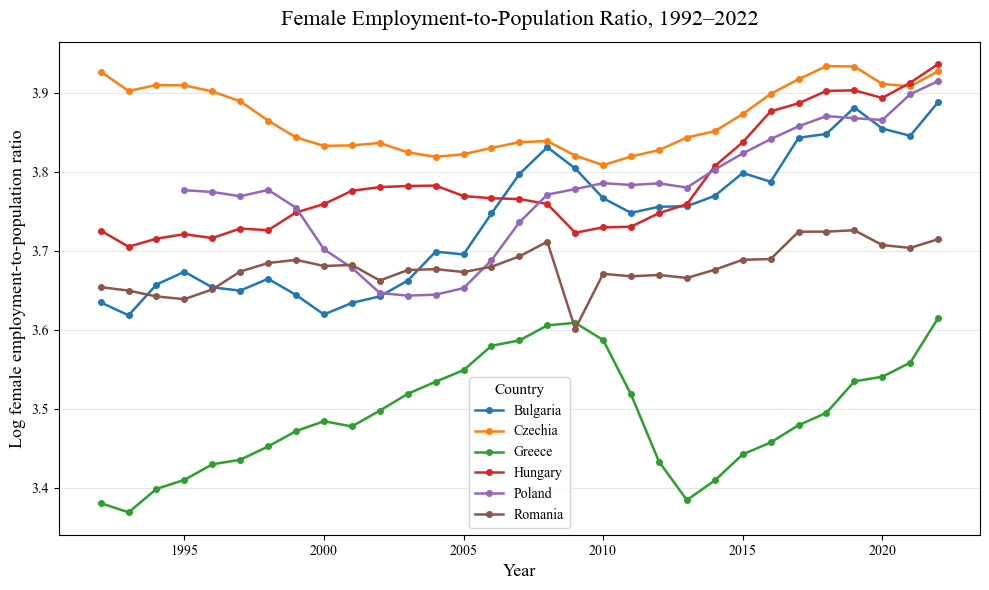

In [7]:
plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(10, 6))

for country, sub in df.groupby("country"):
    sub = sub.sort_values("year")

    ax.plot(
        sub["year"],
        sub["lerf"],
        marker="o",
        linewidth=1.8,
        markersize=4,
        label=country
    )

ax.set_title(
    "Female Employment-to-Population Ratio, 1992–2022",
    fontsize=16,
    pad=12
)

ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Log female employment-to-population ratio", fontsize=13)

ax.grid(axis="y", alpha=0.3)
ax.legend(title="Country", fontsize=10, title_fontsize=11)

plt.tight_layout()

output_path = VISUALS_DIR / "trend_female_employment.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

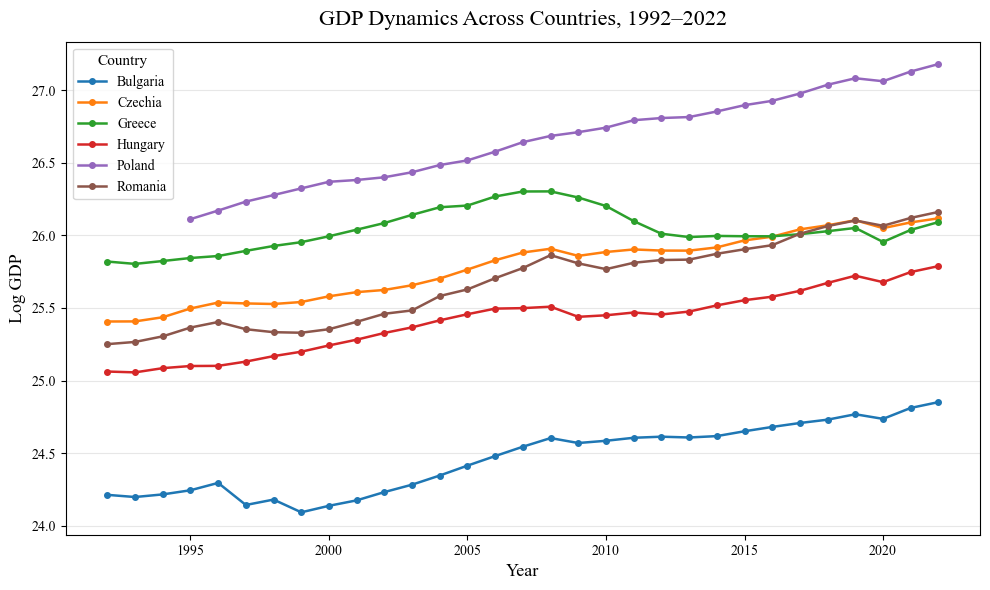

In [9]:
plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(10, 6))

for country, sub in df.groupby("country"):
    sub = sub.sort_values("year")

    ax.plot(
        sub["year"],
        sub["lgdp"],
        marker="o",
        linewidth=1.8,
        markersize=4,
        label=country
    )

ax.set_title(
    "GDP Dynamics Across Countries, 1992–2022",
    fontsize=16,
    pad=12
)

ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Log GDP", fontsize=13)

ax.grid(axis="y", alpha=0.3)
ax.legend(title="Country", fontsize=10, title_fontsize=11)

plt.tight_layout()

output_path = VISUALS_DIR / "trend_gdp.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

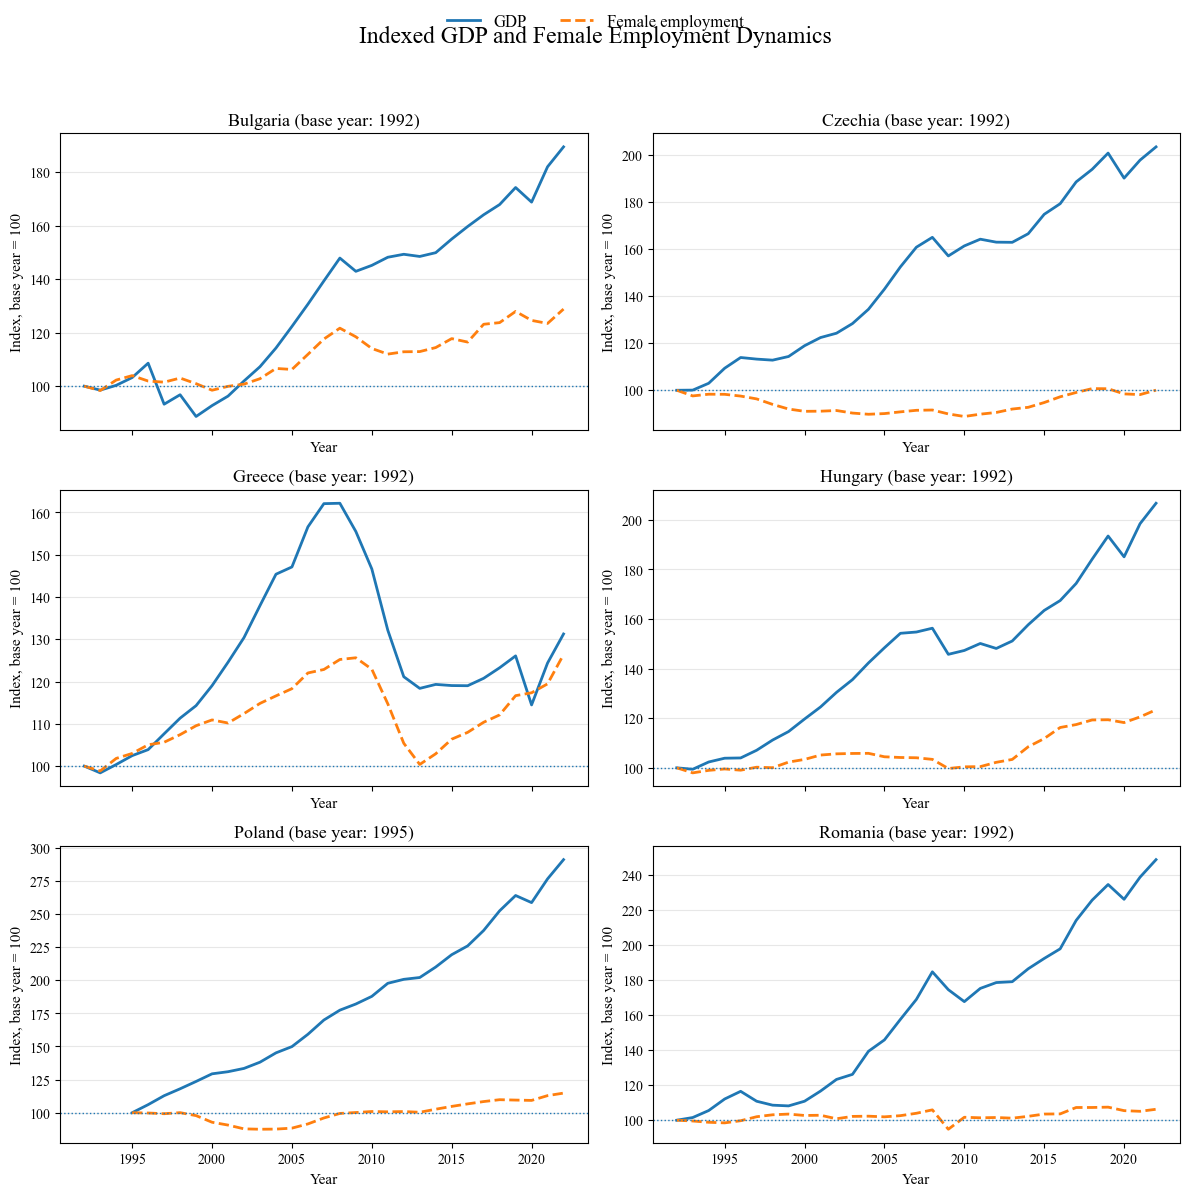

In [15]:

VISUALS_DIR.mkdir(parents=True, exist_ok=True)

df_indexed = df.copy()

base_values = (
    df_indexed
    .sort_values(["country", "year"])
    .groupby("country", as_index=False)
    .first()[["country", "year", "lgdp", "lerf"]]
    .rename(columns={
        "year": "base_year",
        "lgdp": "lgdp_base",
        "lerf": "lerf_base"
    })
)

df_indexed = df_indexed.merge(base_values, on="country", how="left")

df_indexed["gdp_index"] = np.exp(df_indexed["lgdp"] - df_indexed["lgdp_base"]) * 100
df_indexed["erf_index"] = np.exp(df_indexed["lerf"] - df_indexed["lerf_base"]) * 100

plt.rcParams["font.family"] = "Times New Roman"

countries = sorted(df_indexed["country"].unique())

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 12),
    sharex=True
)

axes = axes.flatten()

for ax, country in zip(axes, countries):
    sub = df_indexed[df_indexed["country"] == country].sort_values("year")

    base_year = int(sub["base_year"].iloc[0])

    ax.plot(
        sub["year"],
        sub["gdp_index"],
        linewidth=2,
        label="GDP"
    )

    ax.plot(
        sub["year"],
        sub["erf_index"],
        linewidth=2,
        linestyle="--",
        label="Female employment"
    )

    ax.axhline(100, linewidth=1, linestyle=":")
    ax.set_title(f"{country} (base year: {base_year})", fontsize=13)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Index, base year = 100", fontsize=11)
    ax.grid(axis="y", alpha=0.3)

for ax in axes[len(countries):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    fontsize=12,
    frameon=False
)

fig.suptitle(
    "Indexed GDP and Female Employment Dynamics",
    fontsize=17,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

output_path = VISUALS_DIR / "indexed_gdp_female_employment.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()